In [ ]:
# Build the nucleus and load base data from the utils module
import os
import sys

# Ensure the parent folder is on the import path so shared modules can be loaded.
sys.path.insert(0, os.path.abspath('..'))

from col_amazon_fire_utils import initialize_ee, get_nucleus_geometry

import pandas as pd

ee = initialize_ee(project='col-amazon-fire-susceptibility')

nucleus_geom = get_nucleus_geometry()

In [8]:

import os
from col_amazon_fire_utils import get_burned_df, get_climate_df

data_dir = os.path.abspath(os.path.join('..', 'datasets'))
os.makedirs(data_dir, exist_ok=True)

burned_csv = os.path.join(data_dir, 'burned_df.csv')
climate_csv = os.path.join(data_dir, 'climate_df.csv')

if os.path.exists(burned_csv) and os.path.exists(climate_csv):
    print('Loading existing intermediate datasets...')
    burned_df = pd.read_csv(burned_csv)
    climate_df = pd.read_csv(climate_csv)
else:
    print('Computing burned and climate datasets...')
    burned_df = get_burned_df(nucleus_geom)
    climate_df = get_climate_df(nucleus_geom)
    burned_df.to_csv(burned_csv, index=False)
    climate_df.to_csv(climate_csv, index=False)
    print(f'Saved burned_df to {burned_csv}')
    print(f'Saved climate_df to {climate_csv}')

print(climate_df.round(2))

Loading existing intermediate datasets...
    year  temp_C  precip_mm  wind_ms  rh_pct  vpd_kPa  solar_MJ_m2  ndvi
0   2001   24.44     441.26     0.91   80.08     0.61       567.05  0.81
1   2002   25.22     465.41     0.95   81.35     0.61       549.66  0.75
2   2003   25.54     361.60     0.73   79.57     0.67       564.19  0.80
3   2004   25.75     375.16     1.05   74.70     0.86       577.06  0.73
4   2005   25.33     467.42     0.90   82.89     0.55       551.50  0.78
5   2006   25.13     473.95     1.07   80.75     0.62       558.78  0.78
6   2007   26.11     352.95     0.93   74.83     0.90       575.26  0.78
7   2008   25.23     449.95     1.09   78.01     0.71       567.04  0.80
8   2009   25.03     524.71     1.12   82.29     0.57       544.56  0.76
9   2010   26.02     381.36     0.69   79.73     0.68       573.48  0.77
10  2011   25.22     430.28     1.14   79.71     0.66       567.97  0.79
11  2012   24.86     543.45     1.07   82.75     0.55       537.12  0.77
12  2013 

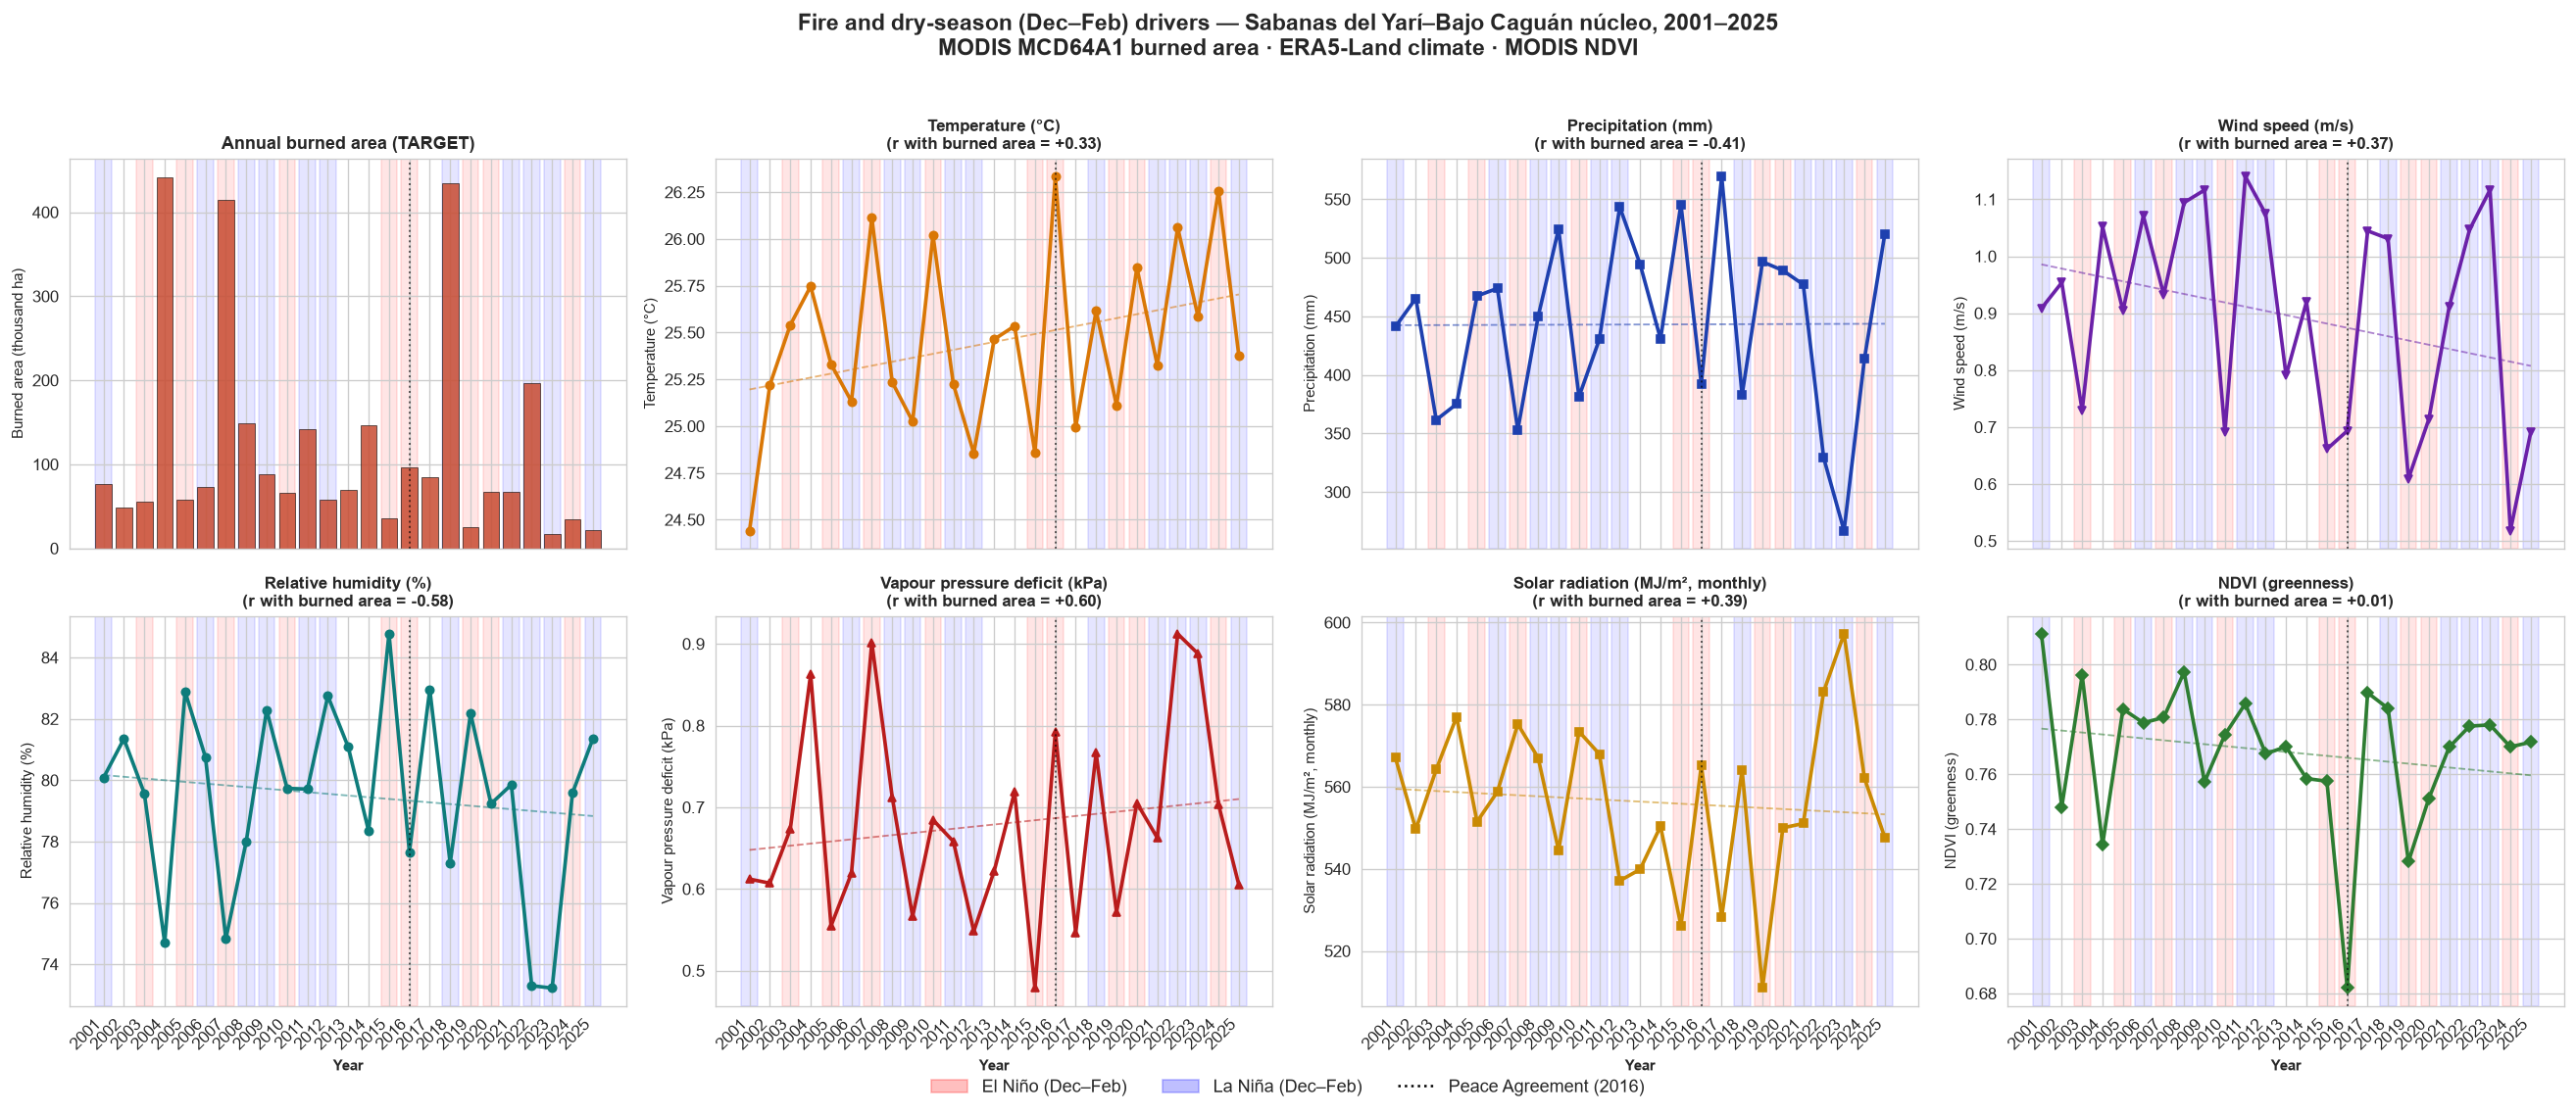

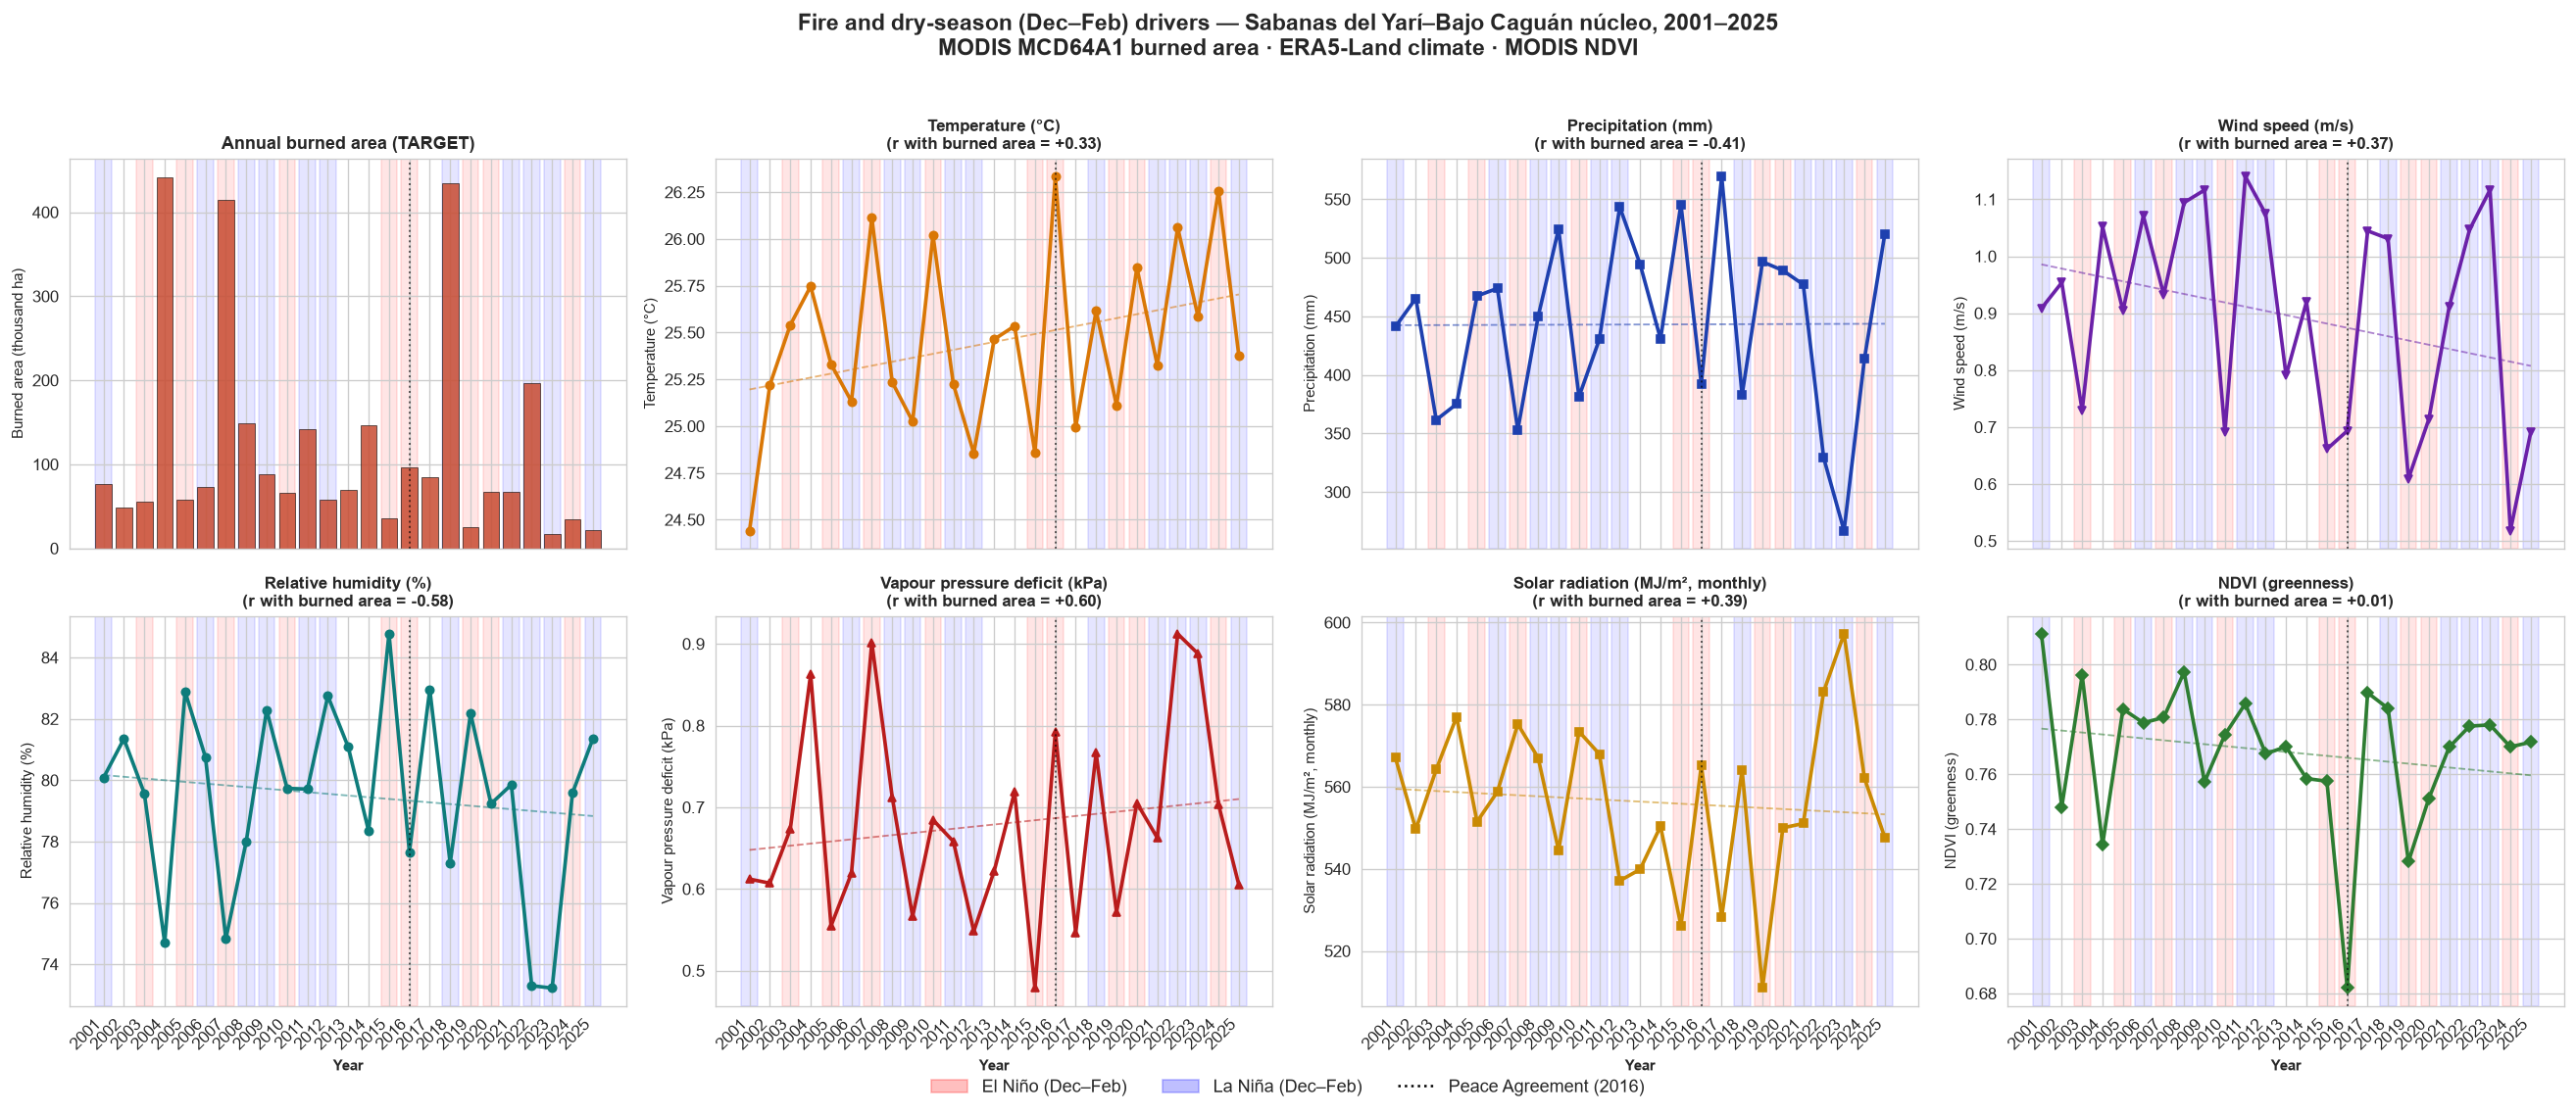

In [10]:
import os
from plot_helpers import plot_fire_and_climate

fig = plot_fire_and_climate(
    burned_df,
    climate_df,
    output_path=os.path.abspath(os.path.join('..', 'datasets', 'fire_and_drivers_panel.png'))
)
fig